# Online CAPTCHA inference with a MAP-centered proposal

This notebook fits `AutoMAPProposal` to an image from `data/examples`,
draws exact-discrete proposal particles, and corrects them against the
original generative model with self-normalized importance weights.

$$
\widetilde z^*=\operatorname*{argmax}_{\widetilde z}
\log\gamma_{\theta,\eta}(\widetilde z;x),\qquad
\widetilde w_s=
\frac{\gamma_\theta(z^{(s)};x)/q_\phi(z^{(s)}\mid x)}
{\sum_r\gamma_\theta(z^{(r)};x)/q_\phi(z^{(r)}\mid x)}.
$$

The reconstruction is $\sum_s\widetilde w_s\mu_\theta(z^{(s)})$.

The model is `configs/model/poisson_convsc_gmrf`: two Gaussian random
fields, one for paper and one for ink, composited with `over`, under a
Gamma--Normal partitioned GMRF likelihood. Its predecessor fixed the paper
to pure white, which made tiling the canvas with glyphs the global mode
by tens of thousands of nats; each config records the measurement that
set it.

In [1]:
from pathlib import Path

import hydra
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import rootutils
from PIL import Image

PROJECT_ROOT = rootutils.setup_root(
    Path.cwd(), indicator=".project-root", pythonpath=True
)

CONFIG_DIRECTORY = str(PROJECT_ROOT / "configs")

In [2]:
EXAMPLE_INDEX = 0
SEED = 0


def load_image(path, shape=(80, 80)):
    height, width = shape
    image = Image.open(path).convert("RGB").resize((width, height))
    array = np.asarray(image, dtype=np.float32) / 255.0
    return jnp.asarray(array)[None]

## Inspect the available observations

Change `EXAMPLE_INDEX` above to fit a different image. The inference cells
operate on whichever path is selected from this gallery.

The five examples added on 2026-09-03 are a harder generator than the
five before them: tinted paper, scattered speckles, a distractor stroke,
and glyphs turned by 10 to 25 degrees. `EXAMPLE_INDEX = 0` selects
`0000_LJ`, whose two glyphs are both turned about 25 degrees; rotating the
template raises its matched-filter score by 70%.

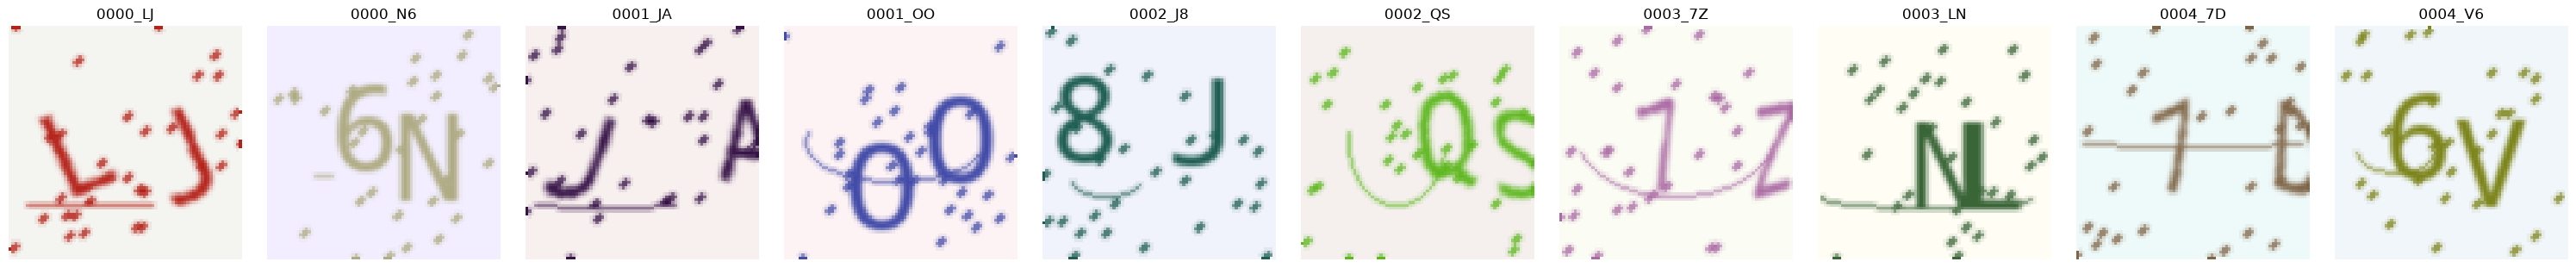

In [3]:
example_paths = sorted((PROJECT_ROOT / "data/examples").glob("*.png"))
if not example_paths:
    raise FileNotFoundError(PROJECT_ROOT / "data/examples")

figure, axes = plt.subplots(
    1, len(example_paths), figsize=(3 * len(example_paths), 3),
    constrained_layout=True, squeeze=False,
)
for axis, path in zip(axes[0], example_paths):
    axis.imshow(np.asarray(load_image(path)[0]))
    axis.set_title(path.stem)
    axis.set_axis_off()
selected_path = example_paths[EXAMPLE_INDEX]

## Fit and reuse the proposal

The first Adam fit locates a mode of the DSGD-relaxed target. The second
uses fresh Monte Carlo particles at each Adam step to fit the proposal
dispersions. After `fit` returns, drawing exact importance particles does
not optimize or otherwise modify the reusable fitted proposal.
Every one of the $H\times W\times K$ Poisson count coordinates remains
in the optimization and in the fitted proposal.

Both the model and the fitter come from configs, so this notebook and
`scripts/online_map_proposal.py` cannot drift apart. The count field
starts at its own prior mean rather than at `AutoMAPProposal`'s
support-aware default, which placed 417,081 glyph stamps and drove the
likelihood gradient on every count coordinate to exactly zero. That is
an optimizer starting point, not a warm start: it uses the model's rate
and nothing derived from the observation, so no candidate set and no
matched filter decides which sites begin with count mass. The full
canonical texture, paper field, and image warp remain latent.

In [4]:
with hydra.initialize_config_dir(
    config_dir=CONFIG_DIRECTORY, version_base="1.3"
):
    model_config = hydra.compose(config_name="model/poisson_convsc_gmrf")
    online_config = hydra.compose(config_name="online/map_proposal")
model_config.model.placements.shape_dict.path = str(
    PROJECT_ROOT / "data/captcha_sandbox/dictionary"
)
model = hydra.utils.instantiate(model_config.model)
inference = hydra.utils.instantiate(online_config.online)(model)

images = load_image(
    selected_path,
    (model.keywords["placements"].height,
     model.keywords["placements"].width),
)
result = inference(jax.random.key(SEED), images)

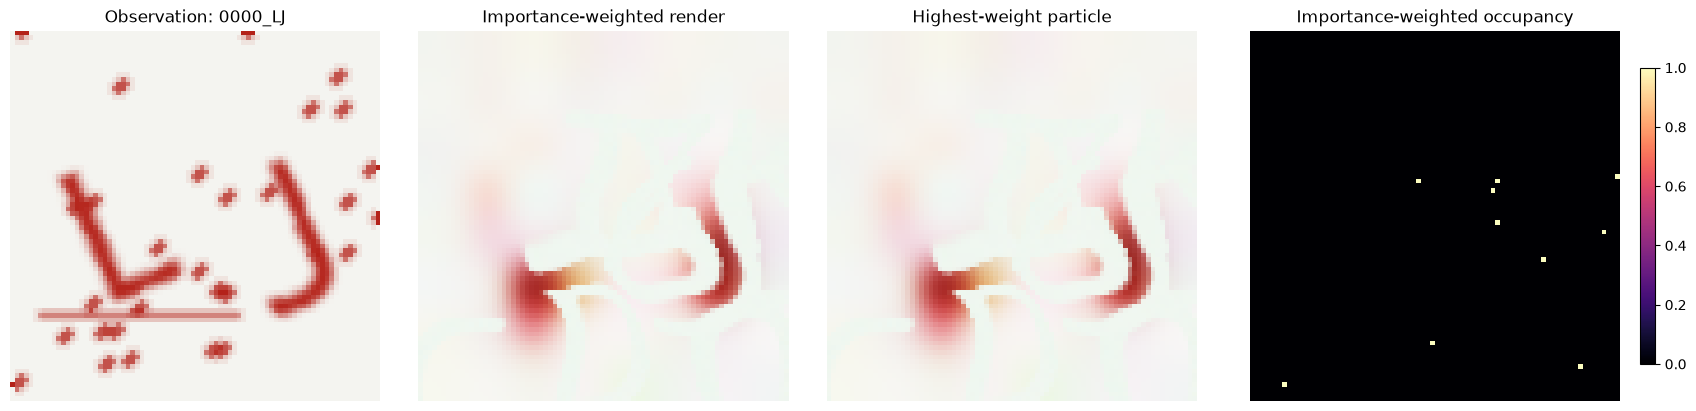

In [5]:
normalized_weights = np.asarray(result.normalized_weights)
top_particle = int(np.argmax(normalized_weights))
weighted_counts = np.asarray(result.weighted_counts)[0]
weighted_occupancy = weighted_counts.sum(axis=-1)
weighted_reconstruction = np.asarray(result.weighted_reconstruction)[0]

figure, axes = plt.subplots(1, 4, figsize=(17, 4),
                            constrained_layout=True)
axes[0].imshow(np.asarray(images[0]))
axes[0].set_title(f"Observation: {selected_path.stem}")
axes[1].imshow(np.clip(weighted_reconstruction, 0.0, 1.0))
axes[1].set_title("Importance-weighted render")
axes[2].imshow(np.clip(
    np.asarray(result.reconstructions[top_particle, 0]), 0.0, 1.0
))
axes[2].set_title("Highest-weight particle")
occupancy_image = axes[3].imshow(weighted_occupancy, cmap="magma")
axes[3].set_title("Importance-weighted occupancy")
figure.colorbar(occupancy_image, ax=axes[3], shrink=0.8)
for axis in axes:
    axis.set_axis_off()

local precision quantiles: [0.022 0.316 1.58  4.102 7.908]
reconstruction RMSE: 0.1267


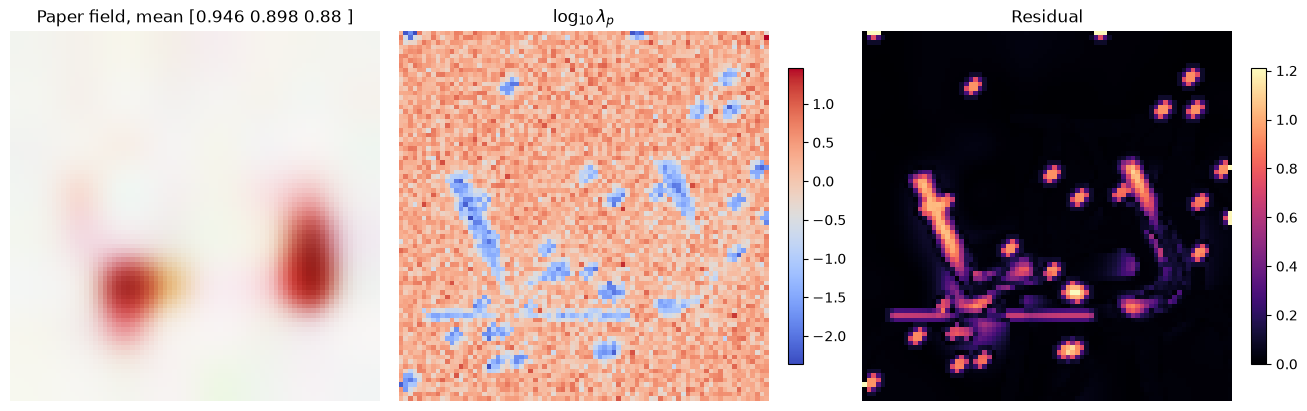

In [6]:
# The two new latent fields. The paper field says what the model believes the
# sheet looks like under the ink; the Gamma precisions say which pixels it has
# given up on explaining, which is where the speckles and the distractor stroke
# should land.
paper_module = model.keywords["backgrounder"]
paper_image = np.asarray(jax.nn.sigmoid(
    result.samples["paper_logit"][top_particle, 0][None, None, :]
    + paper_module.resize_field(
        result.samples["paper_field"][top_particle, 0]
    )
))
precision = np.asarray(result.samples["local_precision"][top_particle, 0])
residual = np.linalg.norm(
    np.asarray(images[0]) - weighted_reconstruction, axis=-1
)

figure, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
axes[0].imshow(np.clip(paper_image, 0.0, 1.0))
axes[0].set_title(
    f"Paper field, mean {paper_image.mean(axis=(0, 1)).round(3)}"
)
precision_image = axes[1].imshow(np.log10(precision), cmap="coolwarm")
axes[1].set_title(r"$\log_{10}\lambda_p$")
figure.colorbar(precision_image, ax=axes[1], shrink=0.8)
residual_image = axes[2].imshow(residual, cmap="magma", vmin=0.0)
axes[2].set_title("Residual")
figure.colorbar(residual_image, ax=axes[2], shrink=0.8)
for axis in axes:
    axis.set_axis_off()

quantiles = np.quantile(precision, [0.01, 0.1, 0.5, 0.9, 0.99])
print(f"local precision quantiles: {quantiles.round(3)}")
print(f"reconstruction RMSE: {np.sqrt((residual ** 2).mean() / 3):.4f}")

MAP: 1500 steps, converged=False, first/last loss 1124714.8 / -33207.4
Dispersion: 500 steps, converged=False, first/last loss -15236.6 / -32595.9
ESS: 1.00 / 64
Largest weight: 1.0000
Expected total glyph count: 10.000
Largest site/class expectation: 1.000


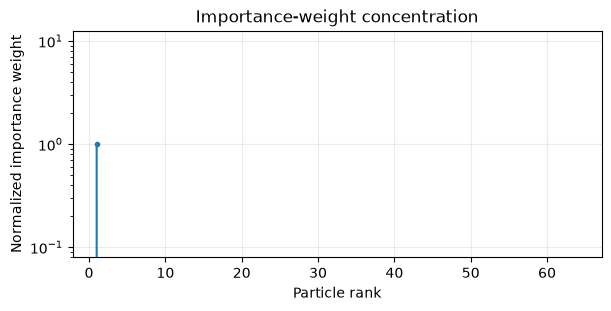

In [7]:
ordered_weights = np.sort(normalized_weights)[::-1]
figure, axis = plt.subplots(figsize=(6, 3), constrained_layout=True)
axis.semilogy(np.arange(1, len(ordered_weights) + 1),
              ordered_weights, marker=".")
axis.set_xlabel("Particle rank")
axis.set_ylabel("Normalized importance weight")
axis.set_title("Importance-weight concentration")
axis.grid(alpha=0.25)

map_steps = int(result.map_num_steps)
dispersion_steps = int(result.dispersion_num_steps)
map_interval = online_config.online.termination_check_interval
print(f"MAP: {map_steps} steps, "
      f"converged={bool(result.map_converged)}, "
      f"first/last loss {float(result.map_losses[0]):.1f} / "
      f"{float(result.map_losses[-1]):.1f}")
print(f"Dispersion: {dispersion_steps} steps, "
      f"converged={bool(result.dispersion_converged)}, "
      f"first/last loss {float(result.dispersion_losses[0]):.1f} / "
      f"{float(result.dispersion_losses[-1]):.1f}")
if map_interval > map_steps:
    print("  WARNING: termination_check_interval exceeds the steps taken, "
          "so `converged` is False by construction and means nothing.")
print(f"ESS: {float(result.effective_sample_size):.2f} / "
      f"{inference.num_importance_samples}")
print(f"Largest weight: {float(ordered_weights[0]):.4f}")
print(f"Expected total glyph count: {weighted_counts.sum():.3f}")
print(f"Largest site/class expectation: {weighted_counts.max():.3f}")
assert np.isfinite(weighted_reconstruction).all()
assert np.isfinite(result.map_losses).all(), "MAP loss went non-finite"
assert np.isfinite(result.dispersion_losses).all(), (
    "dispersion loss went non-finite; the Gamma-count log PMF has hit an "
    "underflowed incomplete-gamma tail, see src/inference/count_relaxation.py"
)
assert np.isclose(normalized_weights.sum(), 1.0)

## Interpretation

Read the expected total glyph count first. The prior expects about four
spikes in the whole image. A total in the hundreds of thousands means the
count field is saturated, the optical depth has run away, and
`dA/dtau = exp(-tau)` has underflowed to zero, so the likelihood is
contributing no gradient to the counts at all and only the Poisson prior
is still pushing.

Then read the two loss histories. Both maximum-step settings are safety
caps, and `converged` is only meaningful when
`termination_check_interval` is smaller than the steps actually taken.
A non-finite dispersion loss is a specific failure and not a fitting
problem: the Gamma-count log PMF takes the logarithm of an
incomplete-gamma tail that has underflowed, which gives the right value
and a NaN derivative, and `eval_and_stable_update` then discards every
proposal update. `src/inference/count_relaxation.py` repairs it and
explains why no choice of `dsgd_kwargs["width"]` can.

Read ESS last, and read it as a statement about dimension rather than
about fit quality. The latent state here is about 233,000 dimensional,
and the count sites that carry a glyph alone contribute roughly
$\log(\lambda_{\text{prior}}/\lambda_{\text{proposal}})\approx-11$ nats
of log-weight spread each time their count moves by one. A factorized
proposal in that many dimensions gives an ESS near one however well it is
fitted, so 64 particles cannot fix it. ESS near one says the estimator is
a reweighting of essentially one mode; it does not say the mode is
wrong, and a good reconstruction with an ESS of one is a real result
about the mode, reported honestly.